In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv("../data/oxidative_stress_data_clean.csv")
markers = ["MDA", "GSH", "GpX", "GRD", "SOD"]
group_order = ["Normal Control", "Atherosclerotic Control", "Low-Dose NAC", "High-Dose NAC", "NAC Treatment"]
df["Group"] = pd.Categorical(df["Group"], categories=group_order, ordered=True)

print(f"Dataset: {df.shape[0]} animals, {len(markers)} biomarkers, {df['Group'].nunique()} groups")
df.head()

Dataset: 25 animals, 5 biomarkers, 5 groups


,Group,Animal_ID,MDA,GSH,GpX,GRD,SOD
0,Normal Control,NOR_1,168.0,42.9,121.0,62.0,11.2
1,Normal Control,NOR_2,138.0,58.0,119.0,40.0,13.4
2,Normal Control,NOR_3,162.0,45.6,108.0,48.0,9.4
3,Normal Control,NOR_4,145.0,46.6,111.6,53.0,14.1
4,Normal Control,NOR_5,144.0,57.4,121.6,49.0,12.8


## Note on Statistical Methodology

Normality was assessed on the **ANOVA residuals** (value − group mean) 
rather than on pooled raw values across all five experimental groups. 
Testing pooled raw data is a common methodological pitfall: when group 
means differ substantially (as expected under a strong treatment 
effect), the pooled distribution becomes artificially multimodal, 
which can produce false rejections of normality even when each group's 
underlying distribution and the model's error term is genuinely 
Gaussian. The residual-based approach below reflects the correct 
assumption check for one-way ANOVA.

In [2]:
print("="*65)
print("ASSUMPTION TESTING (Corrected: testing ANOVA residuals)")
print("="*65)

assumption_results = []
for marker in markers:
    # Compute residuals: each value minus its OWN group mean
    group_means = df.groupby("Group")[marker].transform("mean")
    residuals = df[marker] - group_means

    # Shapiro-Wilk on residuals (the statistically correct approach for ANOVA)
    _, p_shapiro = shapiro(residuals)

    # Levene's test (unchanged - already correct)
    groups_vals = [df[df["Group"]==g][marker].values for g in group_order]
    _, p_levene = levene(*groups_vals)

    assumption_results.append({
        "Biomarker": marker,
        "Shapiro-Wilk p (residuals)": round(p_shapiro, 4),
        "Normal? (p>0.05)": "✅" if p_shapiro > 0.05 else "❌",
        "Levene's p": round(p_levene, 4),
        "Equal Variance? (p>0.05)": "✅" if p_levene > 0.05 else "❌"
    })

assumptions_df = pd.DataFrame(assumption_results)
assumptions_df

ASSUMPTION TESTING (Corrected: testing ANOVA residuals)


,Biomarker,Shapiro-Wilk p (residuals),Normal? (p>0.05),Levene's p,Equal Variance? (p>0.05)
0,MDA,0.8494,✅,0.6648,✅
1,GSH,0.1763,✅,0.5495,✅
2,GpX,0.2663,✅,0.9838,✅
3,GRD,0.2216,✅,0.3785,✅
4,SOD,0.6738,✅,0.3256,✅


In [3]:
print("="*65)
print("ONE-WAY ANOVA RESULTS")
print("="*65)

anova_results = []
for marker in markers:
    groups_vals = [df[df["Group"]==g][marker].values for g in group_order]
    f_stat, p_val = f_oneway(*groups_vals)
    anova_results.append({
        "Biomarker": marker,
        "F-statistic": round(f_stat, 3),
        "p-value": f"{p_val:.2e}" if p_val < 0.0001 else round(p_val, 4),
        "Significant?": "✅ p<0.05" if p_val < 0.05 else "❌ NS"
    })

anova_df = pd.DataFrame(anova_results)
anova_df

ONE-WAY ANOVA RESULTS


,Biomarker,F-statistic,p-value,Significant?
0,MDA,18.248,1.87e-06,✅ p<0.05
1,GSH,15.008,8.08e-06,✅ p<0.05
2,GpX,17.242,2.88e-06,✅ p<0.05
3,GRD,28.815,4.76e-08,✅ p<0.05
4,SOD,60.495,6.88e-11,✅ p<0.05


In [4]:
def get_tukey_letters(marker):
    """Run Tukey HSD and convert pairwise results into compact letter display (a,b,c...)."""
    tukey = pairwise_tukeyhsd(endog=df[marker], groups=df["Group"], alpha=0.05)
    
    # Build a matrix of significant differences
    groups = group_order
    n = len(groups)
    sig_matrix = pd.DataFrame(np.zeros((n,n), dtype=bool), index=groups, columns=groups)
    
    for row in tukey.summary().data[1:]:
        g1, g2, _, p_adj, _, _, reject = row
        sig_matrix.loc[g1, g2] = reject
        sig_matrix.loc[g2, g1] = reject

    # Assign letters: groups sharing no significant difference share a letter
    means = df.groupby("Group")[marker].mean().reindex(groups)
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    letters = {g: "" for g in groups}
    current_letter = ord('a')
    assigned = set()
    
    for g in sorted_groups:
        if g in assigned:
            continue
        letters[g] += chr(current_letter)
        assigned.add(g)
        for g2 in sorted_groups:
            if g2 != g and not sig_matrix.loc[g, g2]:
                letters[g2] += chr(current_letter)
                assigned.add(g2)
        current_letter += 1
    
    return letters, tukey

print("="*65)
print("TUKEY HSD POST-HOC — SUPERSCRIPT LETTERS")
print("="*65)

all_letters = {}
for marker in markers:
    letters, tukey_obj = get_tukey_letters(marker)
    all_letters[marker] = letters
    print(f"\n--- {marker} ---")
    for g in group_order:
        mean_val = df[df["Group"]==g][marker].mean()
        sem_val = df[df["Group"]==g][marker].sem()
        print(f"  {g:28s}: {mean_val:7.2f} ± {sem_val:5.2f}  ({letters[g]})")

TUKEY HSD POST-HOC — SUPERSCRIPT LETTERS

--- MDA ---
  Normal Control              :  151.40 ±  5.76  (c)
  Atherosclerotic Control     :  268.20 ±  7.01  (a)
  Low-Dose NAC                :  182.00 ± 11.43  (bc)
  High-Dose NAC               :  160.00 ± 13.61  (c)
  NAC Treatment               :  215.20 ± 14.91  (b)

--- GSH ---
  Normal Control              :   50.10 ±  3.16  (a)
  Atherosclerotic Control     :   24.86 ±  0.93  (b)
  Low-Dose NAC                :   40.68 ±  3.65  (ab)
  High-Dose NAC               :   46.43 ±  2.51  (a)
  NAC Treatment               :   33.98 ±  1.81  (b)

--- GpX ---
  Normal Control              :  116.24 ±  2.72  (a)
  Atherosclerotic Control     :   77.02 ±  3.12  (c)
  Low-Dose NAC                :   92.34 ±  3.46  (b)
  High-Dose NAC               :  101.08 ±  4.04  (b)
  NAC Treatment               :   90.12 ±  3.94  (bc)

--- GRD ---
  Normal Control              :   50.40 ±  3.59  (a)
  Atherosclerotic Control     :   23.88 ±  1.77  (c)
  L

In [5]:
summary_rows = []
for g in group_order:
    row = {"Group": g}
    for marker in markers:
        mean_val = df[df["Group"]==g][marker].mean()
        sem_val = df[df["Group"]==g][marker].sem()
        letter = all_letters[marker][g]
        row[marker] = f"{mean_val:.2f} ± {sem_val:.2f} {letter}"
    summary_rows.append(row)

summary_table = pd.DataFrame(summary_rows).set_index("Group")
summary_table.to_csv("../data/summary_table_with_letters.csv")
print("✅ Summary table saved.")
summary_table

✅ Summary table saved.


,MDA,GSH,GpX,GRD,SOD
Group,,,,,
Normal Control,151.40 ± 5.76 c,50.10 ± 3.16 a,116.24 ± 2.72 a,50.40 ± 3.59 a,12.18 ± 0.84 a
Atherosclerotic Control,268.20 ± 7.01 a,24.86 ± 0.93 b,77.02 ± 3.12 c,23.88 ± 1.77 c,2.21 ± 0.27 d
Low-Dose NAC,182.00 ± 11.43 bc,40.68 ± 3.65 ab,92.34 ± 3.46 b,36.08 ± 1.97 b,4.78 ± 0.31 c
High-Dose NAC,160.00 ± 13.61 c,46.43 ± 2.51 a,101.08 ± 4.04 b,46.40 ± 1.23 a,9.00 ± 0.44 b
NAC Treatment,215.20 ± 14.91 b,33.98 ± 1.81 b,90.12 ± 3.94 bc,28.70 ± 0.84 bc,3.34 ± 0.60 cd


In [6]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_mda = pairwise_tukeyhsd(endog=df["MDA"], groups=df["Group"], alpha=0.05)
print(tukey_mda.summary())

              Multiple Comparison of Means - Tukey HSD, FWER=0.05               
         group1             group2     meandiff p-adj    lower    upper   reject
--------------------------------------------------------------------------------
Atherosclerotic Control  High-Dose NAC   -108.2    0.0 -155.3483 -61.0517   True
Atherosclerotic Control   Low-Dose NAC    -86.2 0.0002 -133.3483 -39.0517   True
Atherosclerotic Control  NAC Treatment    -53.0 0.0229 -100.1483  -5.8517   True
Atherosclerotic Control Normal Control   -116.8    0.0 -163.9483 -69.6517   True
          High-Dose NAC   Low-Dose NAC     22.0 0.6369  -25.1483  69.1483  False
          High-Dose NAC  NAC Treatment     55.2 0.0169    8.0517 102.3483   True
          High-Dose NAC Normal Control     -8.6 0.9812  -55.7483  38.5483  False
           Low-Dose NAC  NAC Treatment     33.2 0.2556  -13.9483  80.3483  False
           Low-Dose NAC Normal Control    -30.6 0.3286  -77.7483  16.5483  False
          NAC Treatment Norm

✅ Setup done: {'MDA': {'Normal Control': 'c', 'Atherosclerotic Control': 'a', 'Low-Dose NAC': 'bc', 'High-Dose NAC': 'c', 'NAC Treatment': 'b'}, 'GSH': {'Normal Control': 'a', 'Atherosclerotic Control': 'c', 'Low-Dose NAC': 'ab', 'High-Dose NAC': 'a', 'NAC Treatment': 'bc'}, 'GpX': {'Normal Control': 'a', 'Atherosclerotic Control': 'c', 'Low-Dose NAC': 'b', 'High-Dose NAC': 'b', 'NAC Treatment': 'bc'}, 'GRD': {'Normal Control': 'a', 'Atherosclerotic Control': 'c', 'Low-Dose NAC': 'b', 'High-Dose NAC': 'a', 'NAC Treatment': 'bc'}, 'SOD': {'Normal Control': 'a', 'Atherosclerotic Control': 'd', 'Low-Dose NAC': 'c', 'High-Dose NAC': 'b', 'NAC Treatment': 'cd'}}


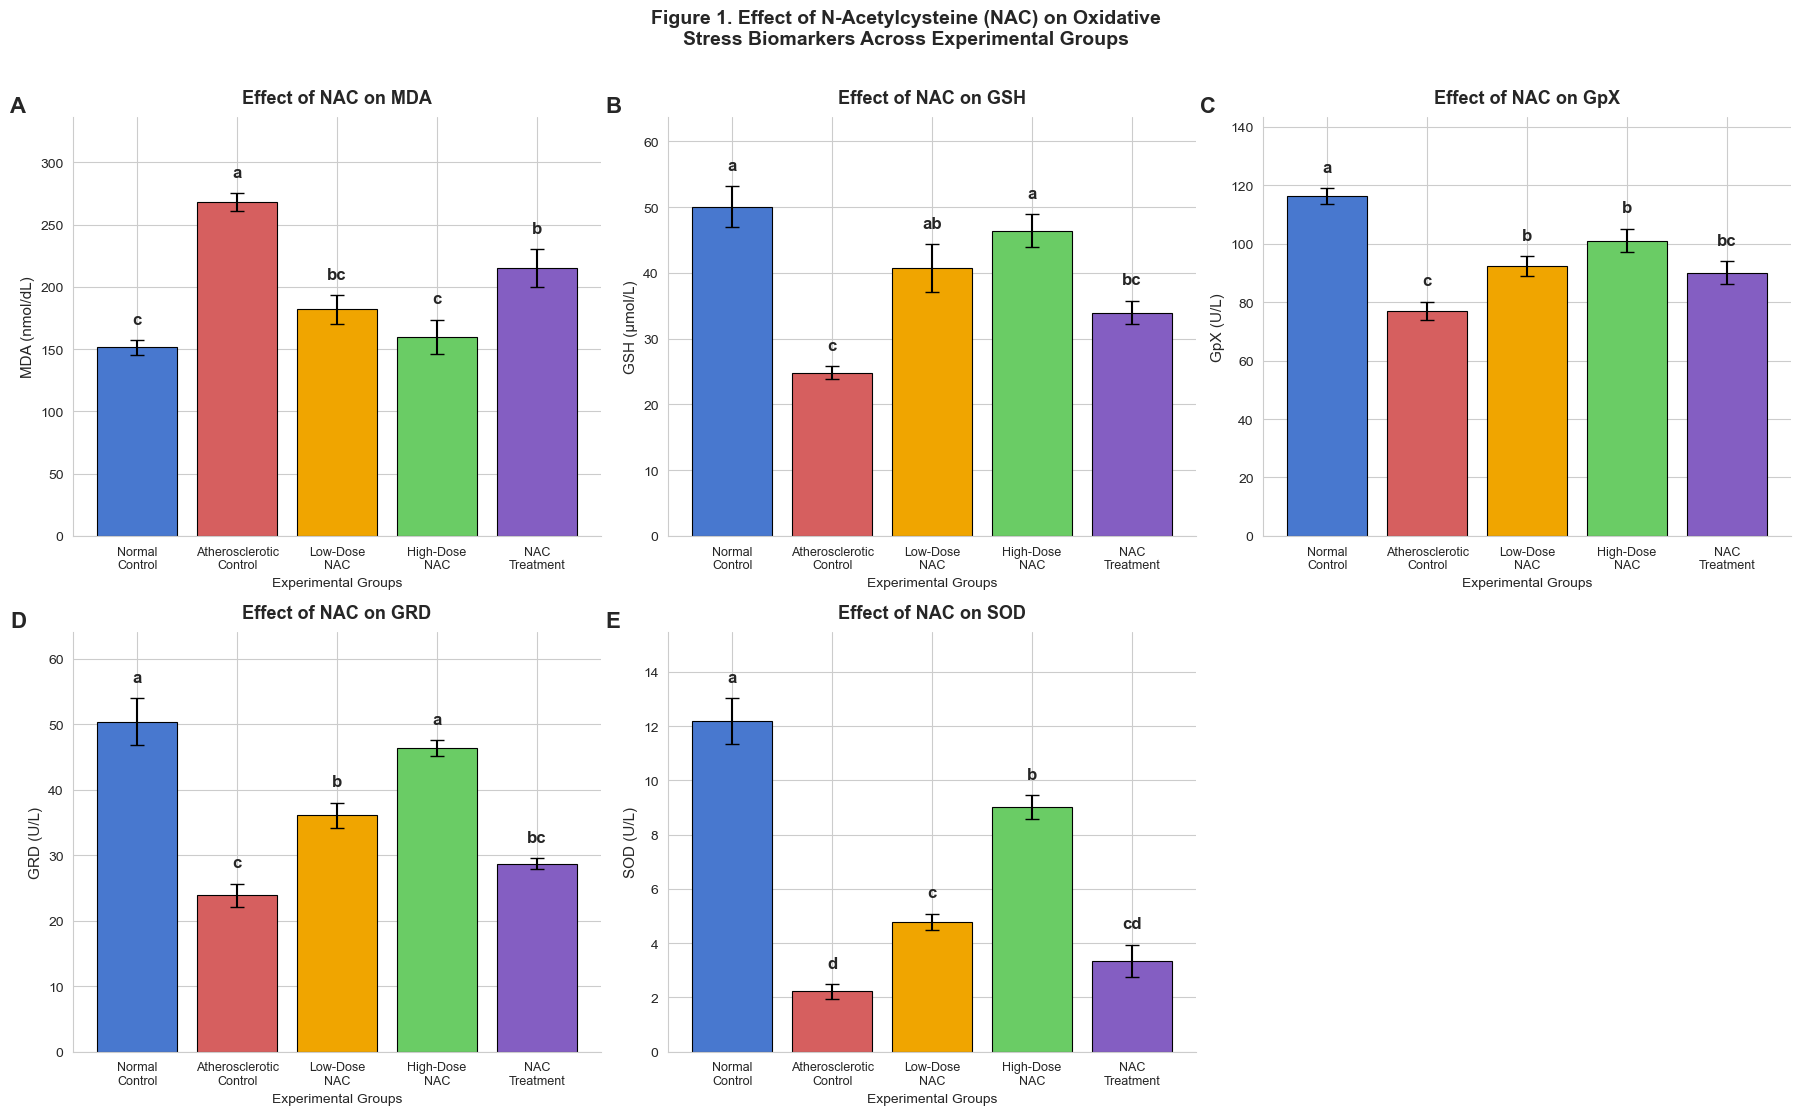

✅ Figure 1 saved


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# ── Load data ─────────────────────────────────────────────────
df = pd.read_csv("../data/oxidative_stress_data_clean.csv")

markers     = ["MDA", "GSH", "GpX", "GRD", "SOD"]
group_order = ["Normal Control", "Atherosclerotic Control",
               "Low-Dose NAC",  "High-Dose NAC", "NAC Treatment"]
df["Group"] = pd.Categorical(df["Group"], categories=group_order, ordered=True)

colors       = ["#4878CF", "#D65F5F", "#F0A500", "#6ACC65", "#845EC2"]
units        = {"MDA":"nmol/dL","GSH":"µmol/L","GpX":"U/L","GRD":"U/L","SOD":"U/L"}
panel_labels = ["A","B","C","D","E"]

# ── CLD Letters ───────────────────────────────────────────────
def get_correct_cld_letters(marker):
    tukey = pairwise_tukeyhsd(endog=df[marker], 
                               groups=df["Group"], alpha=0.05)
    G = nx.Graph()
    G.add_nodes_from(group_order)
    for row in tukey.summary().data[1:]:
        g1, g2, _, p_adj, _, _, reject = row
        if not reject:
            G.add_edge(g1, g2)
    maximal_cliques = list(nx.find_cliques(G))
    group_means = df.groupby("Group")[marker].mean()
    maximal_cliques.sort(
        key=lambda c: -max(group_means[g] for g in c))
    letters = {g: "" for g in group_order}
    for i, clique in enumerate(maximal_cliques):
        letter = chr(ord('a') + i)
        for g in clique:
            letters[g] += letter
    for g in letters:
        letters[g] = "".join(sorted(letters[g]))
    return letters

all_letters_corrected = {m: get_correct_cld_letters(m) for m in markers}
print("✅ Setup done:", {m: all_letters_corrected[m] for m in markers})

# ── Figure 1: Bar Charts ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for idx, marker in enumerate(markers):
    ax = axes[idx]
    means   = df.groupby("Group", sort=False)[marker].mean().reindex(group_order)
    sems    = df.groupby("Group", sort=False)[marker].sem().reindex(group_order)
    letters = all_letters_corrected[marker]

    ax.bar(range(len(group_order)), means,
           yerr=sems, capsize=5,
           color=colors, edgecolor="black", linewidth=0.8,
           error_kw={"elinewidth": 1.5, "ecolor": "black"})

    for i, (mean, sem, g) in enumerate(zip(means, sems, group_order)):
        ax.text(i, mean + sem + (means.max() * 0.04),
                letters[g], ha="center", va="bottom",
                fontsize=12, fontweight="bold")

    ax.set_title(f"Effect of NAC on {marker}",
                 fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel(f"{marker} ({units[marker]})", fontsize=11)
    ax.set_xticks(range(len(group_order)))
    ax.set_xticklabels(["Normal\nControl","Atherosclerotic\nControl",
                         "Low-Dose\nNAC","High-Dose\nNAC","NAC\nTreatment"],
                        fontsize=9)
    ax.set_xlabel("Experimental Groups", fontsize=10)
    ax.text(-0.12, 1.05, panel_labels[idx],
            transform=ax.transAxes,
            fontsize=16, fontweight="bold", va="top")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(0, means.max() + sems.max() + means.max() * 0.2)

axes[5].set_visible(False)

plt.suptitle("Figure 1. Effect of N-Acetylcysteine (NAC) on Oxidative\n"
             "Stress Biomarkers Across Experimental Groups",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../figures/Figure1_barcharts.png", 
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 1 saved")

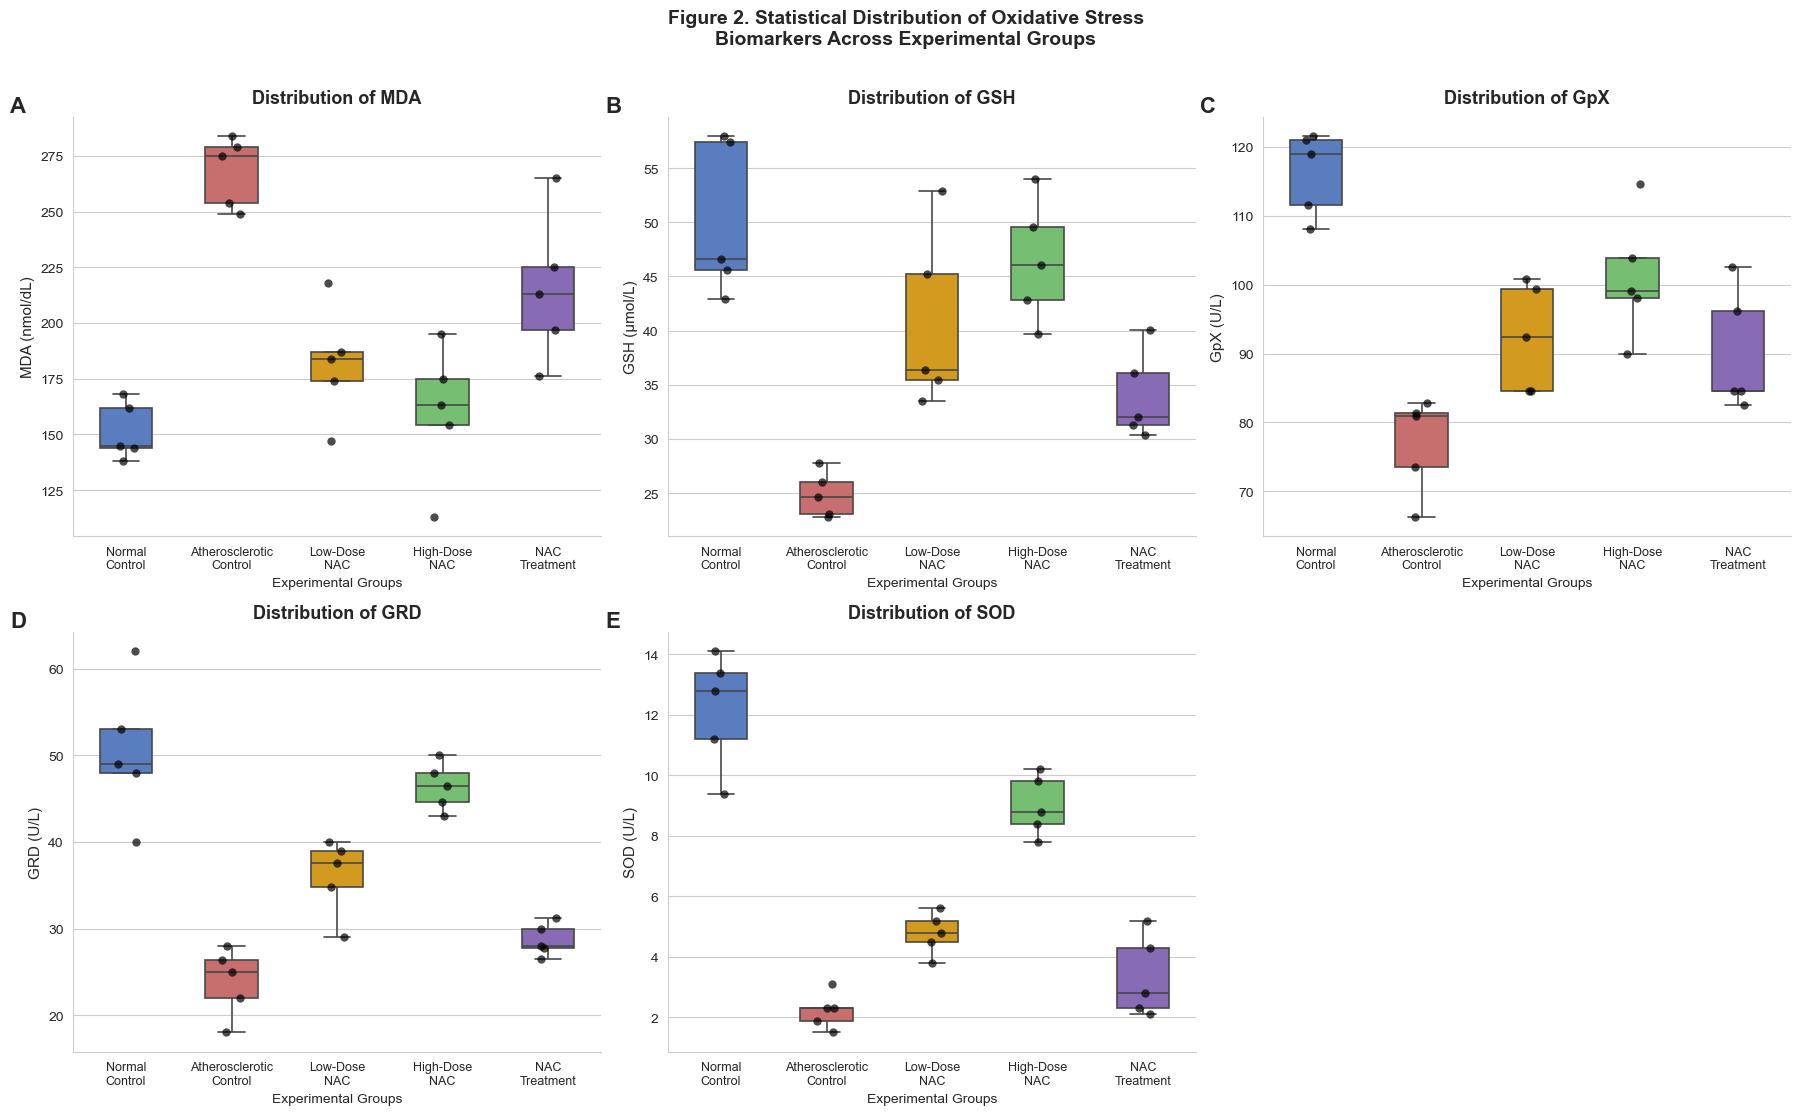

✅ Figure 2 saved to ../figures/Figure2_boxplots.png


In [9]:
# ── Cell 8: Boxplots (Figure 2) ────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

palette = {"Normal Control":          "#4878CF",
           "Atherosclerotic Control": "#D65F5F",
           "Low-Dose NAC":            "#F0A500",
           "High-Dose NAC":           "#6ACC65",
           "NAC Treatment":           "#845EC2"}

for idx, marker in enumerate(markers):
    ax = axes[idx]

    sns.boxplot(data=df, x="Group", y=marker,
                order=group_order, palette=palette,
                width=0.5, linewidth=1.2,
                fliersize=0, ax=ax)

    # Jitter overlay
    sns.stripplot(data=df, x="Group", y=marker,
                  order=group_order, color="black",
                  size=6, alpha=0.7, jitter=True, ax=ax)

    ax.set_title(f"Distribution of {marker}", 
                 fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel(f"{marker} ({units[marker]})", fontsize=11)
    ax.set_xlabel("Experimental Groups", fontsize=10)
    ax.set_xticklabels(["Normal\nControl", "Atherosclerotic\nControl",
                         "Low-Dose\nNAC", "High-Dose\nNAC", "NAC\nTreatment"],
                        fontsize=9)

    ax.text(-0.12, 1.05, panel_labels[idx], transform=ax.transAxes,
            fontsize=16, fontweight="bold", va="top")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[5].set_visible(False)

plt.suptitle("Figure 2. Statistical Distribution of Oxidative Stress\n"
             "Biomarkers Across Experimental Groups",
             fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("../figures/Figure2_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 2 saved to ../figures/Figure2_boxplots.png")

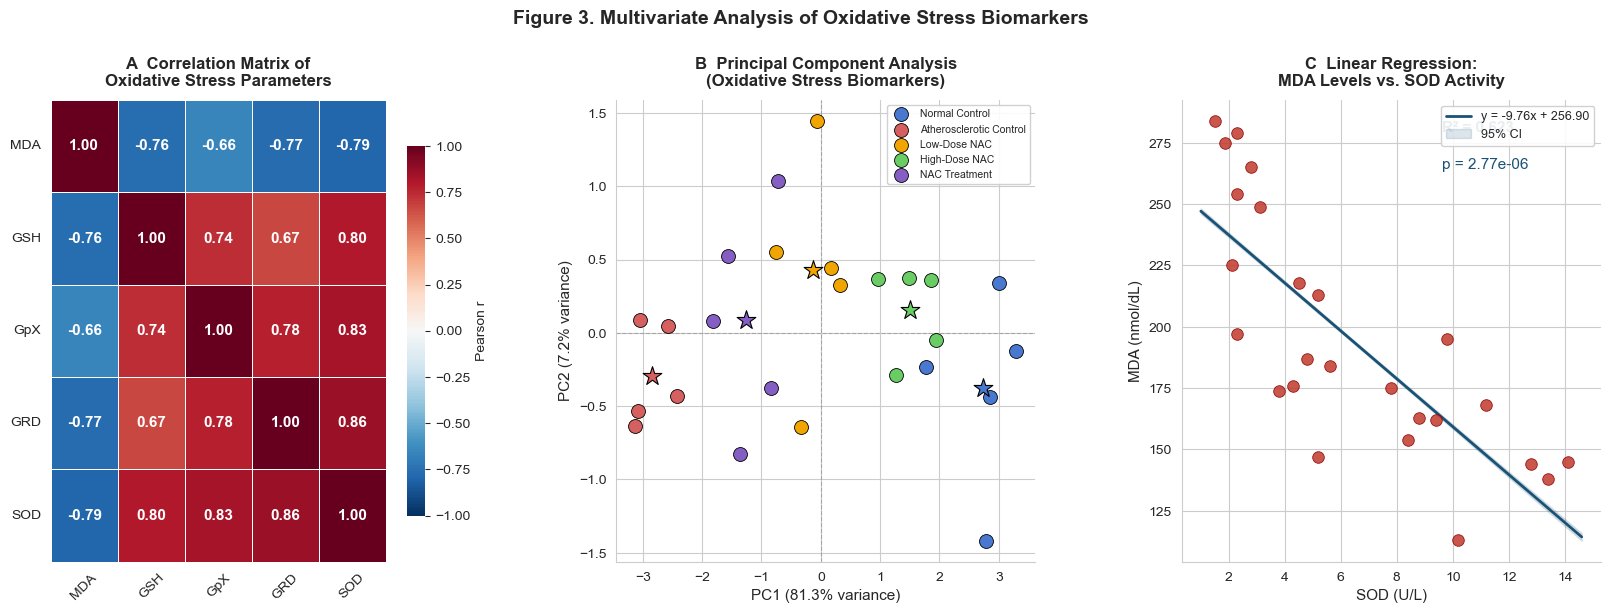

✅ Figure 3 saved
   PCA: PC1=81.3%, PC2=7.2%, Total=88.6%
   Regression: R²=0.623, p=2.77e-06, slope=-9.764


In [10]:
# ── Cell 9: Correlation Heatmap + PCA + Linear Regression ──────

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

fig = plt.figure(figsize=(20, 6))
gs  = fig.add_gridspec(1, 3, wspace=0.35)

# ── Panel A: Pearson Correlation Heatmap ──────────────────────
ax1 = fig.add_subplot(gs[0])
corr_matrix = df[markers].corr(method="pearson").round(2)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, ax=ax1,
            annot=True, fmt=".2f", annot_kws={"size": 11, "weight": "bold"},
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})

ax1.set_title("A  Correlation Matrix of\nOxidative Stress Parameters",
              fontsize=12, fontweight="bold", pad=10)
ax1.tick_params(axis="x", rotation=45)
ax1.tick_params(axis="y", rotation=0)

# ── Panel B: PCA Score Plot ────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[markers])
pca = PCA(n_components=2)
scores = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame({"PC1": scores[:,0], "PC2": scores[:,1],
                        "Group": df["Group"]})

for i, g in enumerate(group_order):
    sub = pca_df[pca_df["Group"] == g]
    ax2.scatter(sub["PC1"], sub["PC2"],
                color=colors[i], label=g, s=100, 
                edgecolor="black", linewidth=0.6, zorder=3)
    # Group centroid
    ax2.scatter(sub["PC1"].mean(), sub["PC2"].mean(),
                color=colors[i], s=200, marker="*",
                edgecolor="black", linewidth=0.8, zorder=4)

ax2.set_xlabel(f"PC1 ({var_exp[0]:.1f}% variance)", fontsize=11)
ax2.set_ylabel(f"PC2 ({var_exp[1]:.1f}% variance)", fontsize=11)
ax2.set_title("B  Principal Component Analysis\n(Oxidative Stress Biomarkers)",
              fontsize=12, fontweight="bold", pad=10)
ax2.legend(fontsize=7.5, loc="best", framealpha=0.9)
ax2.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
ax2.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# ── Panel C: Linear Regression MDA vs SOD ────────────────────
ax3 = fig.add_subplot(gs[2])

x = df["SOD"].values
y = df["MDA"].values
slope, intercept, r_value, p_value, se = stats.linregress(x, y)
r2 = r_value**2

x_line = np.linspace(x.min() - 0.5, x.max() + 0.5, 200)
y_line = slope * x_line + intercept

# Confidence interval (95%)
n = len(x)
x_mean = x.mean()
se_line = se * np.sqrt(1/n + (x_line - x_mean)**2 / np.sum((x - x_mean)**2))
t_crit = stats.t.ppf(0.975, df=n-2)
ci_upper = y_line + t_crit * se_line
ci_lower = y_line - t_crit * se_line

ax3.scatter(x, y, color="#C0392B", s=70, 
            edgecolor="darkred", linewidth=0.6, zorder=3, alpha=0.85)
ax3.plot(x_line, y_line, color="#1A5276", linewidth=2, label=f"y = {slope:.2f}x + {intercept:.2f}")
ax3.fill_between(x_line, ci_lower, ci_upper, alpha=0.15, color="#1A5276", label="95% CI")

ax3.set_xlabel("SOD (U/L)", fontsize=11)
ax3.set_ylabel("MDA (nmol/dL)", fontsize=11)
ax3.set_title("C  Linear Regression:\nMDA Levels vs. SOD Activity",
              fontsize=12, fontweight="bold", pad=10)
ax3.text(0.62, 0.93, f"R² = {r2:.3f}", transform=ax3.transAxes,
         fontsize=11, fontweight="bold", color="#1A5276")
ax3.text(0.62, 0.85, f"p = {p_value:.2e}", transform=ax3.transAxes,
         fontsize=11, color="#1A5276")
ax3.legend(fontsize=9, framealpha=0.9)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

plt.suptitle("Figure 3. Multivariate Analysis of Oxidative Stress Biomarkers",
             fontsize=14, fontweight="bold", y=1.03)

plt.savefig("../figures/Figure3_corr_pca_regression.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Figure 3 saved")
print(f"   PCA: PC1={var_exp[0]:.1f}%, PC2={var_exp[1]:.1f}%, Total={sum(var_exp):.1f}%")
print(f"   Regression: R²={r2:.3f}, p={p_value:.2e}, slope={slope:.3f}")

# ── Cell 10: Generate Project README ───────────────────────────

readme = """
# Oxidative Stress Biomarker Analysis in Atherosclerosis
### A Python-based Statistical & Multivariate Analysis Pipeline

[![Python](https://img.shields.io/badge/Python-3.10-blue?logo=python)](https://python.org)
[![Jupyter](https://img.shields.io/badge/Jupyter-Lab-orange?logo=jupyter)](https://jupyter.org)
[![License: MIT](https://img.shields.io/badge/License-MIT-green)](LICENSE)

---

## Overview

This repository contains the complete statistical analysis pipeline 
for a master's thesis investigating the **protective and therapeutic 
effects of N-Acetylcysteine (NAC)** against vitamin D3/high-fat-diet-
induced atherosclerosis in a Sprague-Dawley rat model.

**Publication:** Manuscript under review — *Pharmacological Research* (IF 7.0)

---

## Biomarkers Analysed

| Biomarker | Full Name | Role |
|---|---|---|
| MDA | Malondialdehyde | Lipid peroxidation index |
| GSH | Reduced Glutathione | Non-enzymatic antioxidant |
| GpX | Glutathione Peroxidase | Peroxide scavenging |
| GRD | Glutathione Reductase | GSH recycling |
| SOD | Superoxide Dismutase | Primary ROS defence |

---

## Experimental Groups

| Group | Description |
|---|---|
| Normal Control | Standard diet + saline |
| Atherosclerotic Control | HFHC diet + Vitamin D3 |
| Low-Dose NAC | HFHC + 150 mg/kg/day NAC (prophylactic) |
| High-Dose NAC | HFHC + 300 mg/kg/day NAC (prophylactic) |
| NAC Treatment | HFHC + 300 mg/kg/day NAC (therapeutic) |

---

## Analysis Pipeline